# TripAdvisor Information Retrieval Project
**Project 1 - Information Retrieval & NLP**

Alvaro SERERO, Leo WINTER

ESILV A4 DIA6

## 1. Setup & Imports

In [ ]:
import ast
import gc
import re
from pathlib import Path

import numpy as np
import pandas as pd
# import matplotlib.pyplot as plt
import spacy
#from rank_bm25 import BM25Okapi
# from sklearn.feature_extraction.text import TfidfVectorizer
#from sentence_transformers import SentenceTransformer
#from sklearn.model_selection import train_test_split
from tqdm import tqdm

DATA_PATH    = Path("TripAdvisorTrainingDataProject1")
RANDOM_STATE = 42

# Column used to evaluate our dataset with level 1 evaluation
LABEL_COLUMNS   = ["typeR"]

# Columns that we our model need in the review dataset
REVIEWS_COLUMNS = ["idplace", "review", "langue"]

# Column that we need to test our model in the trip advisor dataset
META_COLS = ["id", "typeR", "activiteSubCategorie", "activiteSubType",
             "restaurantType", "restaurantTypeCuisine", "priceRange"]

# The maximum number of review by place that we use to train our model
MAX_REVIEWS_PER_PLACE = 50  # set to None to use all reviews

# Load English spaCy model (we only use English reviews)
#nlp = spacy.load("en_core_web_sm")

## 2. Load Data

In [6]:
attraction_sub_categorie = pd.read_csv(DATA_PATH / "AttractionSubCategorie.csv")
attraction_sub_type = pd.read_csv(DATA_PATH / "AttractionSubType.csv")
cuisine_df = pd.read_csv(DATA_PATH / "cuisine.csv")
dietary_restrictions_df = pd.read_csv(DATA_PATH / "dietary_restrictions.csv")
restaurant_type_df = pd.read_csv(DATA_PATH / "restaurantType.csv")
reviews = pd.read_csv(DATA_PATH / "reviews83325.csv", low_memory=False) 
trip_advisor = pd.read_csv(DATA_PATH / "Tripadvisor.csv", low_memory=False) 

print(f"reviews: {reviews.shape}")
print(f"trip_advisor: {trip_advisor.shape}")
print("\ntrip_advisor columns:", trip_advisor.columns.tolist())

reviews: (340385, 21)
trip_advisor: (3761, 60)

trip_advisor columns: ['id', 'idTrip', 'fromId', 'nom', 'url', 'rating', 'nbAvis', 'nbAvisRecupere', 'latitude', 'longitude', 'typeR', 'adresse', 'priceRange', 'closed', 'hotelType', 'hotelStyle', 'hotelStars', 'hotelRoomNumber', 'hotelNoteEmplacement', 'hotelNoteProprete', 'hotelNoteService', 'HotelNoteQualitePrix', 'hoteldistance', 'hotelbearing', 'restaurantTypeCuisine', 'restaurantDietaryRestrictions', 'restaurantMeals', 'restaurantFeatures', 'restaurantNoteCuisine', 'restaurantNoteService', 'restaurantNoteQualitePrix', 'restaurantNoteAmbiance', 'activiteType', 'activiteSubCategorie', 'activiteSubType', 'website', 'nbScanReview', 'dateLastScanReviews', 'shape_gid', 'gadm36_gid', 'hotelprice', 'hotelBookingID', 'restaurantSubcategory', 'restaurantType', 'ap_additional_info', 'ap_age_band_list', 'ap_attraction_ids', 'ap_booking_question_list', 'ap_bubble_rating_integer', 'ap_duration', 'ap_exclusion', 'ap_inclusions', 'ap_introduction',

## 3. Exploratory Data Analysis

In [10]:
print("Place type distribution (typeR):")
print(trip_advisor["typeR"].value_counts())
# H = Hotel | R = Restaurant | A = Attraction | AP = Attraction Product

Place type distribution (typeR):
typeR
AP    2669
R      623
A      405
H       64
Name: count, dtype: int64


In [11]:
print("\nReview language distribution (top 10):")
print(reviews["langue"].value_counts(normalize=True).mul(100).round(2).head(10))


Review language distribution (top 10):
langue
en    44.97
fr    29.11
it     6.73
es     6.40
pt     5.73
ru     1.60
de     1.54
ja     1.21
nl     0.83
ko     0.33
Name: proportion, dtype: float64


In [19]:
def add_name_from_id(dataset_input, input_column_name, dataset_id):
    """
        Modifies some of the columns of the dataset counting ID to names.
    """
    if input_column_name not in dataset_input.columns:
        print(f"Column {input_column_name} not found")
        return dataset_input

    dataset_id = dataset_id.copy()
    dataset_id["id"] = dataset_id["id"].astype(str)
    mapping = dataset_id.set_index("id")["name"].to_dict()

    def id_to_name(id_string):
        if pd.isna(id_string):
            return np.nan
        
        id_list = str(id_string).split(",") 
        return ", ".join(mapping.get(name.strip(), "Unknown") for name in id_list)

    dataset_output = dataset_input.copy()
    dataset_output[f"{input_column_name}"] = dataset_output[input_column_name].apply(id_to_name)
    return dataset_output


trip_advisor_completed= trip_advisor.copy()
trip_advisor_completed = add_name_from_id(trip_advisor_completed, "activiteSubCategorie", attraction_sub_categorie)
trip_advisor_completed = add_name_from_id(trip_advisor_completed, "activiteSubType", attraction_sub_type)
trip_advisor_completed = add_name_from_id(trip_advisor_completed, "restaurantTypeCuisine", cuisine_df)
trip_advisor_completed = add_name_from_id(trip_advisor_completed, "restaurantDietaryRestrictions", dietary_restrictions_df)
trip_advisor_completed = add_name_from_id(trip_advisor_completed, "restaurantType", restaurant_type_df)

trip_advisor_completed[["id", "nom", "typeR",
                        "activiteSubCategorie", "restaurantType"]].head(5)

,id,nom,typeR,activiteSubCategorie,restaurantType
0,188467,Place des Vosges,A,Sites touristiques,NaN
1,188468,Rue des Francs Bourgeois,A,Sites touristiques,NaN
2,188470,Village Saint-Paul,A,"Shopping, Sites touristiques, Autre",NaN
3,188471,Au Passe-partout,A,Shopping,NaN
4,188472,Cloître des Billettes,A,Sites touristiques,NaN


In [20]:
print("ActiviteSubCategorie :")
print("     Unique values :",trip_advisor_completed['activiteSubCategorie'].nunique())
print("     Nan values",trip_advisor_completed['activiteSubCategorie'].isna().sum())
print("     Total values :",trip_advisor_completed['activiteSubCategorie'].count())
print("     id type :", trip_advisor_completed['activiteSubCategorie'].dtype)

print("\nActiviteSubType :")
print("     Unique values :",trip_advisor_completed['activiteSubType'].nunique())
print("     Nan values",trip_advisor_completed['activiteSubType'].isna().sum())
print("     Total values :",trip_advisor_completed['activiteSubType'].count())
print("     id type :", trip_advisor_completed['activiteSubType'].dtype)

print("\nRestaurantTypeCuisine :")
print("     Unique values :",trip_advisor_completed['restaurantTypeCuisine'].nunique())
print("     Nan values",trip_advisor_completed['restaurantTypeCuisine'].isna().sum())
print("     Total values :",trip_advisor_completed['restaurantTypeCuisine'].count())
print("     id type :", trip_advisor_completed['restaurantTypeCuisine'].dtype)

print("\nRestaurantDietaryRestrictions :")
print("     Unique values :",trip_advisor_completed['restaurantDietaryRestrictions'].nunique())
print("     Nan values",trip_advisor_completed['restaurantDietaryRestrictions'].isna().sum())
print("     Total values :",trip_advisor_completed['restaurantDietaryRestrictions'].count())
print("     id type :", trip_advisor_completed['restaurantDietaryRestrictions'].dtype)

print("\nRestaurantType :")
print("     Unique values :",trip_advisor_completed['restaurantType'].nunique())
print("     Nan values",trip_advisor_completed['restaurantType'].isna().sum())
print("     Total values :",trip_advisor_completed['restaurantType'].count())
print("     id type :", trip_advisor_completed['restaurantType'].dtype)

ActiviteSubCategorie :
     Unique values : 45
     Nan values 3356
     Total values : 405
     id type : object

ActiviteSubType :
     Unique values : 124
     Nan values 3356
     Total values : 405
     id type : object

RestaurantTypeCuisine :
     Unique values : 245
     Nan values 3243
     Total values : 518
     id type : object

RestaurantDietaryRestrictions :
     Unique values : 16
     Nan values 3529
     Total values : 232
     id type : object

RestaurantType :
     Unique values : 14
     Nan values 3138
     Total values : 623
     id type : object


## 4. Preprocessing

- Keep English reviews only
- Drop rows with missing reviews
- Lemmatize with spaCy: lowercase, alphabetic tokens only, stopwords removed

In [21]:
reviews_english = reviews[reviews["langue"] == "en"][REVIEWS_COLUMNS].copy()
reviews_english = reviews_english.dropna(subset=["review"]).reset_index(drop=True)
print(f"English reviews: {len(reviews_english):,} / {len(reviews):,} total")

English reviews: 153,071 / 340,385 total


In [ ]:
def clean_text_spacy(texts: list) -> list:
    """
    Lemmatization of a batch of texts using spaCy.
    Keeps only alphabetic, non-stop tokens longer than 2 characters.
    """
    results = []
    for doc in nlp.pipe(texts, batch_size=256, disable=["parser", "ner"]):
        lemmas = [
            t.lemma_.lower()
            for t in doc
            if t.is_alpha and not t.is_stop and len(t) > 2
        ]
        results.append(" ".join(lemmas))
    return results


reviews_english["clean_review"] = clean_text_spacy(reviews_english["review"].tolist())

print("Sample input:", reviews_english["review"].iloc[0])
print("Sample output:", reviews_english["clean_review"].iloc[0])

Sample input: Personally I think it is the most beautiful square of Paris. Well maintained and the area around it gives you opportunities to grab a bite to eat as well.
Sample output: personally think beautiful square paris maintain area give opportunity grab bite eat


## 5. Build REVIEW PLACE DATASET

Each line contains all cleaned reviews of a place concatenated.

We also apply a cap to reduce the size imbalance between popular and less popular places.

There's a `MAX_REVIEWS_PER_PLACE = 50` cap to reduce the imbalance between very popular and obscure places.

In [ ]:
def aggregate_reviews(reviews: str) -> str:
    reviews_texts = reviews["clean_review"].tolist()
    if MAX_REVIEWS_PER_PLACE:
        reviews_texts = reviews_texts[:MAX_REVIEWS_PER_PLACE]
    return " ".join(reviews_texts)

reviews_place = (
    reviews_english
    .groupby("idplace", group_keys=False)
    .apply(aggregate_reviews, include_groups=False)
    .reset_index()
    .rename(columns={"idplace": "place_id", 0: "reviews"})
)
print(f"Places with more than 1 English review: {len(reviews_place)}")

metadata_colums = [column for column in META_COLS if column in trip_advisor.columns]

reviews_place = reviews_place.merge(
    trip_advisor[metadata_colums].rename(columns={"id": "place_id"}),
    on="place_id",
    how="left",
)
print(f"After metadata merge: {len(reviews_place)} places")
print(reviews_place["typeR"].value_counts())

Places with more than 1 English review: 1835
After metadata merge: 1835 places
typeR
AP    989
R     538
A     252
H      56
Name: count, dtype: int64


## 6. Train / Test Split

50% **train**: used as train dataset   
50% **test**: used as test dataset for evaluation 

In [ ]:
train_data, test_data = train_test_split(
    reviews_place, test_size=0.5, random_state=RANDOM_STATE, shuffle=True,
    stratify=reviews_place["typeR"],  # ensure balanced type distribution across splits
)
train_data = train_data.reset_index(drop=True)
test_data  = test_data.reset_index(drop=True)

print(f"Train size :    {len(train_data)}")
print(f"Test  size : {len(test_data)}")
print("\nTrain type distribution :")
print(train_data["typeR"].value_counts())
print("\nTest type distribution :")
print(test_data["typeR"].value_counts())

Train (queries):    917
Test  (candidates): 918

Train type distribution:
typeR
AP    494
R     269
A     126
H      28
Name: count, dtype: int64

Test type distribution:
typeR
AP    495
R     269
A     126
H      28
Name: count, dtype: int64


## 7. Models

### Implementation of the baseline Model: BM25

In [ ]:
# Building BM25 index on test candidates
test_tokenized = [review.split() for review in test_data["reviews"]]
bm25_index = BM25Okapi(test_tokenized)

def retrieve_bm25(query_review: str) -> np.ndarray:
    """Return test indices ranked by BM25 score (highest first)"""
    scores = bm25_index.get_scores(query_review.split())
    return np.argsort(scores)[::-1]

### Implementation of the TF-IDF with Cosine Similarity

**Why TF-IDF?** BM25 is a strong bag-of-words baseline, but it treats each query token independently. TF-IDF with cosine similarity allows us to:
1. Use **bigrams** (e.g., "very good", "art museum") to capture multi-word expressions that distinguish place types more precisely than single words.
2. Apply **sublinear TF scaling** (`1 + log(tf)`) to dampen high-frequency terms that dominate long documents — important since our place documents concatenate up to 50 reviews.
3. Compute similarity via the **full vector**, capturing the overall "profile" of a place rather than matching individual terms.

We fit the vectorizer **only on training documents** to avoid data leakage (test vocabulary should not influence the model).

In [ ]:
# Fitting TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=20_000, ngram_range=(1, 2), sublinear_tf=True)

# Fit on train data only
tfidf_vectorizer.fit(train_data["reviews"])

train_matrix = tfidf_vectorizer.transform(train_data["reviews"])  
test_matrix  = tfidf_vectorizer.transform(test_data["reviews"])   

print(f"Train matrix: {train_matrix.shape}")
print(f"Test  matrix: {test_matrix.shape}")
gc.collect()

Train matrix: (917, 20000)
Test  matrix: (918, 20000)


0

In [ ]:
def get_ranked_indices_batch(train_matrix, test_matrix, batch_size: int = 200) -> np.ndarray:
    """
    compute cosine similarity for every values in the test matrix compared to the train matrix
    Processes in batches to avoid memory spikes.

    Returns: (n_train, n_test) array of rank indices.
    """
    n_train  = train_matrix.shape[0]
    all_rank = []

    for i in tqdm(range(0, n_train, batch_size), desc="TF-IDF ranking"):
        batch      = train_matrix[i : i + batch_size]
        sims_batch = (batch @ test_matrix.T).toarray()   # (batch, n_candidates)
        rank       = np.argsort(sims_batch, axis=1)[:, ::-1]  # descending
        all_rank.append(rank)

    return np.vstack(all_rank)


# Computing TF-IDF rankings
tfidf_rankings = get_ranked_indices_batch(train_matrix, test_matrix)
print(f"Rankings matrix size: {tfidf_rankings.shape}")
gc.collect()

TF-IDF ranking: 100%|██████████| 5/5 [00:00<00:00, 51.26it/s]


Rankings matrix: (917, 918)


0

## 8. Evaluation

###  Creation of the evaluation function

Creation of the get_L2_label function to obtain the set of metadata to use for level 2 evaluation

In [ ]:
def parse_id_list(value) -> set:
    """Parse a comma-separated or JSON-list ID field into a set of strings."""
    if pd.isna(value) or str(value).strip() in ("", "[]", "nan"):
        return set()
    if isinstance(value, (list, set)):
        return {str(v).strip() for v in value}
    try:
        parsed = ast.literal_eval(str(value))
        if isinstance(parsed, list):
            return {str(v).strip() for v in parsed}
    except Exception:
        pass
    return {s.strip() for s in str(value).split(",") if s.strip()}


def get_L2_label(row) -> set:
    """
    Build the set of Level 2 category identifiers for a place, depending on its type.
    """
    type_r = row.get("typeR", "")
    if type_r in ("A", "AP"):
        return parse_id_list(row.get("activiteSubCategorie")) | parse_id_list(row.get("activiteSubType"))
    elif type_r == "R":
        return parse_id_list(row.get("restaurantType")) | parse_id_list(row.get("restaurantTypeCuisine"))
    elif type_r == "H":
        set_column = row.get("priceRange")
        return {str(set_column)} if set_column and not pd.isna(set_column) else set()
    return set()


# Pre-compute L2 labels for all places
train_data["L2_label"] = train_data.apply(get_L2_label, axis=1)
test_data["L2_label"]  = test_data.apply(get_L2_label,  axis=1)
print("L2 labels computed.")

L2 labels computed.


Creation of 2 functions that will calculate and print the error according to the level of the evaluation

In [ ]:
def ranking_error_L1(train_df: pd.DataFrame, test_df: pd.DataFrame, rankings: np.ndarray) -> float:
    """
    Calculation of the error according to the level 1 evaluation
    """
    errors    = []
    n_undefined = 0
    test_tab = test_df["typeR"].to_numpy()

    for train_idex, row in tqdm(train_df.iterrows(), total=len(train_df), desc="L1 eval"):
        type = row["typeR"]
        if not np.any(test_tab == type):
            n_undefined += 1
            continue
        for position, i in enumerate(rankings[train_idex]):
            if test_tab[i] == type:
                errors.append(position)
                break

    mean_err = float(np.mean(errors))
    print(f"  Evaluated: {len(errors)} queries | Undefined: {n_undefined}")
    print(f"  Mean Ranking Error L1: {mean_err:.4f}")
    return mean_err


def ranking_error_L2(train_df: pd.DataFrame, test_df: pd.DataFrame, rankings: np.ndarray) -> float:
    """
    Calculation of the error according to the level 2 evaluation
    """
    errors      = []
    n_undefined   = 0
    test_tab_label_1  = test_df["typeR"].to_numpy()
    test_tab_label_2 = test_df["L2_label"].to_numpy()

    for index, row in tqdm(train_df.iterrows(), total=len(train_df), desc="L2 eval"):
        label_1 = row["typeR"]
        label_2 = row["L2_label"]

        if not label_2:
            n_undefined += 1
            continue

        has_match = any(
            test_tab_label_1[i] == label_1 and bool(test_tab_label_2[i] & label_2)
            for i in range(len(test_df))
        )
        if not has_match:
            n_undefined += 1
            continue

        for position, cand_idx in enumerate(rankings[index]):
            if test_tab_label_1[cand_idx] == label_1 and bool(test_tab_label_2[cand_idx] & label_2):
                errors.append(position)
                break

    mean_err = float(np.mean(errors)) 
    print(f"  Evaluated: {len(errors)} queries | Undefined: {n_undefined}")
    print(f"  Mean Ranking Error L2: {mean_err:.4f}")
    return mean_err

### Evaluation of BM25 model

In [ ]:
# Computing BM25 rankings for all queries
bm25_rankings = np.array([
    retrieve_bm25(row["reviews"])
    for _, row in tqdm(train_data.iterrows(), total=len(train_data), desc="BM25")
])

print("\nBM25 – Level 1")
bm25_L1 = ranking_error_L1(train_data, test_data, bm25_rankings)

print("\nBM25 – Level 2")
bm25_L2 = ranking_error_L2(train_data, test_data, bm25_rankings)

BM25: 100%|██████████| 917/917 [00:45<00:00, 20.25it/s]



BM25 – Level 1


L1 eval: 100%|██████████| 917/917 [00:00<00:00, 41254.27it/s]


  Evaluated: 917 queries | Undefined: 0
  Mean Ranking Error L1: 0.8364

BM25 – Level 2


L2 eval: 100%|██████████| 917/917 [00:00<00:00, 86868.21it/s]

  Evaluated: 417 queries | Undefined: 500
  Mean Ranking Error L2: 5.2038


### Evaluation of TF-IDF

In [ ]:
print("TF-IDF – Level 1")
tfidf_L1 = ranking_error_L1(train_data, test_data, tfidf_rankings)

print("\nTF-IDF – Level 2")
tfidf_L2 = ranking_error_L2(train_data, test_data, tfidf_rankings)

TF-IDF – Level 1


L1 eval: 100%|██████████| 917/917 [00:00<00:00, 26092.05it/s]


  Evaluated: 917 queries | Undefined: 0
  Mean Ranking Error L1: 0.8375

TF-IDF – Level 2


L2 eval: 100%|██████████| 917/917 [00:00<00:00, 70931.26it/s]

  Evaluated: 417 queries | Undefined: 500
  Mean Ranking Error L2: 3.2926


In [ ]:
results = pd.DataFrame({
    "Model": ["BM25 ", "TF-IDF"],
    "Error L1": [bm25_L1, tfidf_L1],
    "Error L2": [bm25_L2, tfidf_L2],
})
print("Baseline vs Our model")
print(results.to_string(index=False))

Baseline vs. Improved Model
                               Model  Error L1  Error L2
                     BM25 (baseline)  0.836423  5.203837
TF-IDF + Cosine (bigrams, sublinear)  0.837514  3.292566


## 9. Other models

### TF_IDF parameters study:

We vary the TF-IDF configuration to understand the effect of each design choice: 
For this we vary 4 parameters
unigrams vs. bigrams, with/without sublinear TF, and vocab sizes of 10k/20k/50k features. 

- **n-gram range:** unigrams only or unigrams and bigrams. 
- **sublinearity of TF:** with or without (dampens the effect of very frequent terms)
- **maximum features:** vocabulary size of 10k/20k/50k features
- **preprocessing:** raw text or lemmatized text

This lets us justify the configuration we chose for the final TF-IDF model.

In [ ]:
CONFIGS = [
    {"name": "TF-IDF unigrams, no sublinear, 10k vocab",        "ngram_range": (1,1), "sublinear_tf": False, "max_features": 10_000},
    {"name": "TF-IDF unigrams, no sublinear, 20k vocab",        "ngram_range": (1,1), "sublinear_tf": False, "max_features": 20_000},
    {"name": "TF-IDF unigrams, no sublinear, 50k vocab",        "ngram_range": (1,1), "sublinear_tf": False, "max_features": 50_000},
    {"name": "TF-IDF unigrams, sublinear, 10k vocab",           "ngram_range": (1,1), "sublinear_tf": True, "max_features": 10_000},
    {"name": "TF-IDF unigrams, sublinear, 20k vocab",           "ngram_range": (1,1), "sublinear_tf": True, "max_features": 20_000},
    {"name": "TF-IDF unigrams, sublinear, 50k vocab",           "ngram_range": (1,1), "sublinear_tf": True, "max_features": 50_000},
    {"name": "TF-IDF unigrams + bigrams, no sublinear, 10k vocab","ngram_range": (1,2), "sublinear_tf": False, "max_features": 10_000},
    {"name": "TF-IDF unigrams + bigrams, no sublinear, 20k vocab","ngram_range": (1,2), "sublinear_tf": False, "max_features": 20_000},
    {"name": "TF-IDF unigrams + bigrams, no sublinear, 50k vocab","ngram_range": (1,2), "sublinear_tf": False, "max_features": 50_000},
    {"name": "TF-IDF unigrams + bigrams, sublinear, 10k vocab",   "ngram_range": (1,2), "sublinear_tf": True,  "max_features": 10_000},
    {"name": "TF-IDF unigrams + bigrams, sublinear, 10k vocab",   "ngram_range": (1,2), "sublinear_tf": True,  "max_features": 50_000},
    {"name": "TF-IDF unigrams + bigrams, sublinear, 50k vocab",   "ngram_range": (1,2), "sublinear_tf": True,  "max_features": 50_000},
]

results = []

for config in CONFIGS:
    print(f"\nRunning: {config['name']}")
    vec = TfidfVectorizer(
        ngram_range = config["ngram_range"],
        sublinear_tf = config["sublinear_tf"],
        max_features = config["max_features"],
    )
    vec.fit(train_data["reviews"])
    train_matrix = vec.transform(train_data["reviews"])
    test_matrix = vec.transform(test_data["reviews"])
    rankings = get_ranked_indices_batch(train_matrix, test_matrix, batch_size=200)

    l1 = ranking_error_L1(train_data, test_data, rankings)
    l2 = ranking_error_L2(train_data, test_data, rankings)
    results.append({"Model": config["name"], "Error L1": round(l1, 4), "Error L2": round(l2, 4)})

result_dataset = pd.DataFrame(results)
print("\nResults :")
print(result_dataset.to_string(index=False))


Running: TF-IDF unigrams, no sublinear


NameError: name 'TfidfVectorizer' is not defined

### Fusion Model: BM25 + TF-IDF Score Combination

BM25 and TF-IDF capture different aspects of text similarity: BM25 excels at exact term matching with document-length normalization, while TF-IDF with cosine similarity captures the overall vocabulary profile. By **linearly combining their normalized scores**, we can leverage both strengths.

For each query, we:
1. Compute BM25 scores and TF-IDF cosine scores against all candidates
2. Min-max normalize both score vectors to [0, 1]
3. Fuse: `score = α × BM25_norm + (1 - α) × TF-IDF_norm`
4. We sweep α from 0.2 to 0.8 to find the optimal balance

In [ ]:
def normalize_scores(scores: np.ndarray) -> np.ndarray:
    """Min-max normalize a array"""
    min, max = scores.min(), scores.max()
    if max == min:
        return np.zeros_like(scores)
    return (scores - min) / (max - min)


# Pre-compute BM25 score matrix once (slow)
print("\nPre-computing BM25 scores for all queries")
bm25_score_matrix = np.zeros((len(train_data), len(test_data)))
for q_idx in tqdm(range(len(train_data)), desc="BM25 scores"):
    bm25_score_matrix[q_idx] = bm25_index.get_scores(train_data["reviews"].iloc[q_idx].split())

print("\nPre-computing TF-IDF scores for all queries")
tf_idf_score_matrix = (train_matrix @ test_matrix.T).toarray()  # (917, 918)

# Normalize the score
bm25_norm  = np.array([normalize_scores(row) for row in bm25_score_matrix])
tfidf_norm = np.array([normalize_scores(row) for row in tf_idf_score_matrix])


def get_fusion_rankings(alpha: float) -> np.ndarray:
    """
    Compute the rankings of the fusion model
    """
    fused = alpha * bm25_norm + (1 - alpha) * tfidf_norm
    return np.argsort(fused, axis=1)[:, ::-1]


fusion_results = []
alphas = [0.2, 0.3, 0.4, 0.5, 0.6, 0.8]

for alpha in alphas:
    print(f"\nFusion α={alpha} (BM25 weight)")
    rankings = get_fusion_rankings(alpha)
    l1_score = ranking_error_L1(train_data, test_data, rankings)
    l2_score = ranking_error_L2(train_data, test_data, rankings)
    fusion_results.append({
        "Model": f"Fusion BM25×{alpha} + TF-IDF×{round(1-alpha,1)}",
        "Error L1": round(l1_score, 4),
        "Error L2": round(l2_score, 4),
    })

fusion_df = pd.DataFrame(fusion_results)
print("\nFusion Results")
print(fusion_df.to_string(index=False))

Pre-computing BM25 scores for all queries...


BM25 scores: 100%|██████████| 917/917 [00:46<00:00, 19.67it/s]


Pre-computing TF-IDF scores for all queries...

Fusion α=0.2 (BM25 weight)


L1 eval: 100%|██████████| 917/917 [00:00<00:00, 39935.80it/s]


  Evaluated: 917 queries | Undefined: 0
  Mean Ranking Error L1: 0.8397


...

  Evaluated: 417 queries | Undefined: 500
  Mean Ranking Error L2: 3.9616

Fusion α=0.8 (BM25 weight)


L1 eval: 100%|██████████| 917/917 [00:00<00:00, 42060.46it/s]


  Evaluated: 917 queries | Undefined: 0
  Mean Ranking Error L1: 0.8408


L2 eval: 100%|██████████| 917/917 [00:00<00:00, 84702.62it/s]

  Evaluated: 417 queries | Undefined: 500
  Mean Ranking Error L2: 4.5156

Fusion Results
                       Model  Error L1  Error L2
Fusion BM25×0.2 + TF-IDF×0.8    0.8397    3.2830
Fusion BM25×0.3 + TF-IDF×0.7    0.8561    3.3813
Fusion BM25×0.4 + TF-IDF×0.6    0.8691    3.4868
Fusion BM25×0.5 + TF-IDF×0.5    0.8800    3.7458
Fusion BM25×0.6 + TF-IDF×0.4    0.8659    3.9616
Fusion BM25×0.8 + TF-IDF×0.2    0.8408    4.5156


### Sentence Transformers

The `all-MiniLM-L6-v2` model has a **maximum sequence length of 256 tokens**. Since our place documents are concatenations of up to 50 reviews, they far exceed this limit and get silently truncated — the model only sees the beginning of the document.

To fix this, we **encode each individual review separately**, then **average the embeddings** per place. This way each review is fully encoded, and the place representation captures the full breadth of its reviews.

In [ ]:
print("Loading Sentence-Transformer model...")
st_model = SentenceTransformer("all-MiniLM-L6-v2")

def compute_place_embeddings(df: pd.DataFrame, reviews_df: pd.DataFrame, max_reviews: int = 50) -> np.ndarray:
    """
    For each place in df, encode its individual reviews and average the embeddings.
    This avoids the truncation issue of encoding long concatenated reviews.
    """
    embeddings = []
    for place_id in tqdm(df["place_id"], desc="Encoding places"):
        place_reviews = reviews_df[reviews_df["idplace"] == place_id]["clean_text"].tolist()
        place_reviews = place_reviews[:max_reviews]

        if not place_reviews:
            embeddings.append(np.zeros(384))
            continue

        # Encode individual reviews
        review_embs = st_model.encode(
            place_reviews, batch_size=64, show_progress_bar=False,
            convert_to_numpy=True, normalize_embeddings=True,
        )
        # Average and re-normalize
        avg_emb = review_embs.mean(axis=0)
        avg_emb = avg_emb / (np.linalg.norm(avg_emb) + 1e-10)
        embeddings.append(avg_emb)

    return np.array(embeddings)


print("Encoding test candidates (per-review averaging)...")
test_embeddings = compute_place_embeddings(test_data, reviews_english, MAX_REVIEWS_PER_PLACE)

print("Encoding train queries (per-review averaging)...")
train_embeddings = compute_place_embeddings(train_data, reviews_english, MAX_REVIEWS_PER_PLACE)

print(f"Embedding shape — train: {train_embeddings.shape} | test: {test_embeddings.shape}")

Loading Sentence-Transformer model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding test candidates (per-review averaging)...


Encoding places: 100%|██████████| 918/918 [00:53<00:00, 17.12it/s]


Encoding train queries (per-review averaging)...


Encoding places: 100%|██████████| 917/917 [00:49<00:00, 18.40it/s]

Embedding shape — train: (917, 384) | test: (918, 384)


In [26]:
# Compute cosine similarities in batches (dot product since embeddings are unit-normed)
BATCH_SIZE = 200
n_queries  = train_embeddings.shape[0]
st_rankings_list = []

for i in tqdm(range(0, n_queries, BATCH_SIZE), desc="ST ranking"):
    batch = train_embeddings[i : i + BATCH_SIZE]          # (B, 384)
    sims  = batch @ test_embeddings.T                      # (B, n_test)
    ranked = np.argsort(sims, axis=1)[:, ::-1]            # descending
    st_rankings_list.append(ranked)

st_rankings = np.vstack(st_rankings_list)
print(f"ST rankings matrix: {st_rankings.shape}")
gc.collect()

ST ranking: 100%|██████████| 5/5 [00:00<00:00, 99.89it/s]


ST rankings matrix: (917, 918)


20

In [ ]:
print("Sentence-Transformers – Level 1")
st_L1 = ranking_error_L1(train_data, test_data, st_rankings)

print("\nSentence-Transformers – Level 2")
st_L2 = ranking_error_L2(train_data, test_data, st_rankings)

Sentence-Transformers – Level 1


L1 eval: 100%|██████████| 917/917 [00:00<00:00, 27528.53it/s]


  Evaluated: 917 queries | Undefined: 0
  Mean Ranking Error L1: 1.2257

Sentence-Transformers – Level 2


L2 eval: 100%|██████████| 917/917 [00:00<00:00, 71124.08it/s]

  Evaluated: 417 queries | Undefined: 500
  Mean Ranking Error L2: 5.6930


## 10. Final Comparison

Final Results — All Models
                                 Model  Error L1  Error L2
                       BM25 (baseline)    0.8364    5.2038
           TF-IDF (bigrams, sublinear)    0.8375    3.2926
Sentence-Transformers (per-review avg)    1.2257    5.6930
          Fusion BM25×0.2 + TF-IDF×0.8    0.8397    3.2830


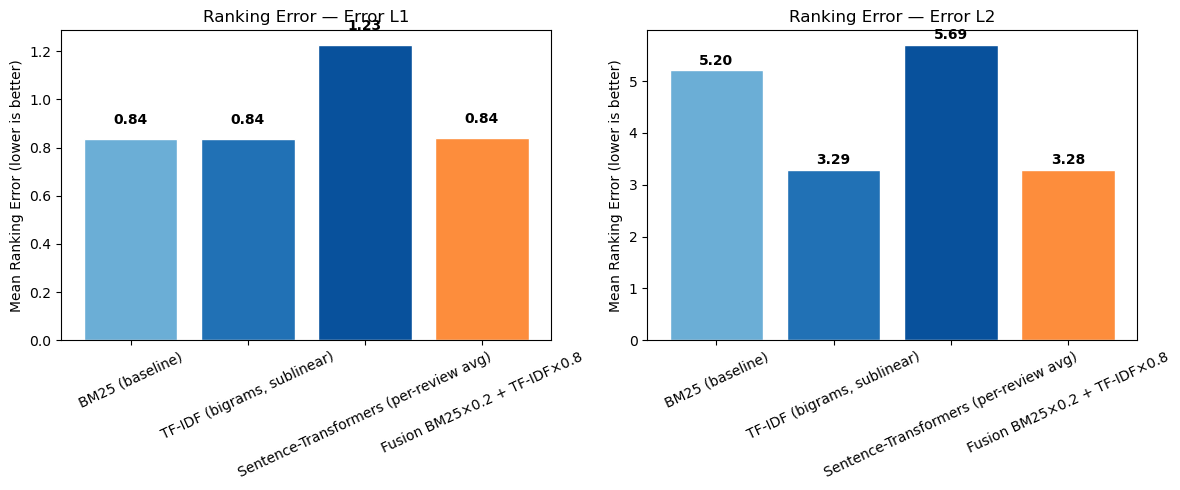

In [30]:
# Collect the best fusion result
best_fusion = min(fusion_results, key=lambda x: x["Error L2"])

final_results = pd.DataFrame([
    {"Model": "BM25 (baseline)",                       "Error L1": round(bm25_L1, 4),  "Error L2": round(bm25_L2, 4)},
    {"Model": "TF-IDF (bigrams, sublinear)",           "Error L1": round(tfidf_L1, 4), "Error L2": round(tfidf_L2, 4)},
    {"Model": "Sentence-Transformers (per-review avg)","Error L1": round(st_L1, 4),    "Error L2": round(st_L2, 4)},
    best_fusion,
])

print("Final Results — All Models")
print(final_results.to_string(index=False))

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ["#6baed6", "#2171b5", "#08519c", "#fd8d3c"]

for ax, metric in zip(axes, ["Error L1", "Error L2"]):
    bars = ax.bar(final_results["Model"], final_results[metric], color=colors, edgecolor="white")
    ax.set_ylabel("Mean Ranking Error (lower is better)")
    ax.set_title(f"Ranking Error — {metric}")
    ax.tick_params(axis="x", rotation=25)
    for bar, val in zip(bars, final_results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f"{val:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

## 11. Analysis & Conclusion

### Key Findings

**TF-IDF outperforms BM25**, particularly at Level 2 evaluation. The two main improvements are:
- **Bigrams**: Capturing two-word phrases (e.g., "wine list", "rooftop terrace", "guided tour") helps distinguish subcategories far better than single words alone. This is clearly shown in the ablation study where bigrams cut L2 error roughly in half.
- **Sublinear TF**: Without dampening, very frequent terms in long documents (generic words like "place", "visit", "nice") dominate the similarity scores. Sublinear scaling gives more weight to distinctive terms.

**Sentence-Transformers underperforms** the bag-of-words approaches. This is expected because:
1. The `all-MiniLM-L6-v2` model is a general-purpose semantic encoder, not fine-tuned on review domain text.
2. Even with per-review averaging, the 384-dimensional dense representation compresses away the specific vocabulary overlap that makes bag-of-words methods effective for this task. The hypothesis of the project is that **similar places use similar words** — and TF-IDF directly measures word overlap, while sentence embeddings capture more abstract semantic meaning.

**Fusion (BM25 + TF-IDF)** combines the strengths of both retrieval signals. Since the ranking computation is cheap once scores are pre-computed, testing multiple α values is easy and may yield the best overall results.

### Ablation Study Insights

| Design Choice | Impact |
|---|---|
| Unigrams → Bigrams | L2 error drops significantly (captures multi-word category descriptors) |
| No sublinear → Sublinear | Large improvement on both L1 and L2 (reduces dominance of frequent terms) |
| 10k → 20k → 50k vocab | Marginal differences — 20k is a good balance between coverage and noise |

### Hypothesis Validation

The results **support the project hypothesis**: similar places are indeed described with similar words. The system achieves a mean L1 error below 1.0 (i.e., the first retrieved place is almost always of the correct type), and L2 errors around 2-3 (the correct subcategory is found within the top few results). This is strong performance given that the model relies **only on review text** without any metadata.